# Práctica 3 · Buscar y responder

En la práctica anterior dejaste los documentos preparados: fragmentos bien formados, cada uno
con su origen anotado. Eso era el flujo que se corre una sola vez.

Hoy toca el otro, el que se dispara con cada pregunta del cliente. Convertir los fragmentos en
vectores, encontrar los que vienen al caso, armar la instrucción para el modelo y, al final,
algo que no habíamos hecho: comprobar si la respuesta es buena en lugar de suponerlo.

<img src="figuras/04_flujo_consulta.svg" alt="Diagrama del flujo de consulta: la pregunta se convierte en vector, se buscan los fragmentos más cercanos en el índice, se arma el prompt con la pregunta y los fragmentos, el modelo genera la respuesta y un evaluador la califica." width="880">

Las celdas se ejecutan en orden, una por una, con Shift + Enter. Este cuaderno es autónomo: no
necesitas haber corrido el anterior en esta sesión.

## 1. Instalar las librerías

Las mismas de la práctica anterior, más `matplotlib` para poder ver los resultados en una
gráfica en lugar de leer listas de números.

In [1]:
%pip install --quiet langchain-community langchain-ollama langchain-text-splitters lancedb pymupdf matplotlib

print("Librerías listas.")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/fgrodriguez/ESAN_GlobalWeek2026/09_Notebooks_RAG/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Librerías listas.


## 2. Comprobar que Ollama responde

Ollama es el programa que ejecuta los modelos de lenguaje dentro de tu computadora. Tiene que
estar encendido para que este cuaderno funcione, así que lo primero es confirmarlo.

Si algo falla, la salida de la celda te dice qué hacer según tu sistema operativo.

In [2]:
import platform
import sys

import requests

OLLAMA_URL = "http://localhost:11434"

print(f"Sistema: {platform.system()} {platform.machine()}")
print(f"Python:  {sys.version.split()[0]}\n")

try:
    respuesta = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    respuesta.raise_for_status()
    modelos = sorted(m["name"] for m in respuesta.json()["models"])
    print(f"Ollama responde. Tienes {len(modelos)} modelos descargados:\n")
    for m in modelos:
        print(f"  - {m}")
except Exception as e:
    print(f"Ollama no responde en {OLLAMA_URL}")
    print(f"Detalle: {type(e).__name__}\n")
    if platform.system() == "Darwin":
        print("En Mac: abre la aplicación Ollama desde la carpeta Aplicaciones.")
        print("Debe aparecer su ícono en la barra de menús, arriba a la derecha.")
    elif platform.system() == "Windows":
        print("En Windows: busca Ollama en el menú Inicio y ábrelo.")
        print("Debe aparecer su ícono junto al reloj, abajo a la derecha.")
    else:
        print("Ejecuta 'ollama serve' en una terminal.")

Sistema: Darwin arm64
Python:  3.12.13



Ollama responde. Tienes 14 modelos descargados:

  - embeddinggemma:300m
  - gemma3:1b
  - gemma3:4b
  - gemma4:12b-mlx
  - gemma4:26b
  - gemma4:e4b
  - granite4.1:3b
  - granite4.1:8b
  - mxbai-embed-large:latest
  - nemotron-mini:4b
  - nomic-embed-text:latest
  - qwen3-4b-cs-ft:latest
  - qwen3:4b
  - shieldgemma:2b


## 3. Elegir el modelo según tu equipo

El modelo va a correr en tu máquina, así que la memoria que tengas importa. Un modelo grande
en un equipo chico no se rompe: simplemente tarda muchísimo y el sistema se pone lento.

Abajo hay tres opciones. Deja activa una sola, la que corresponda a tu computadora, y comenta
las demás poniéndoles un signo de gato al inicio de la línea. Si no sabes cuánta memoria
tienes, quédate con la opción A, que funciona en cualquier equipo.

El modelo de embeddings no se elige por equipo: es ligero y va igual en todos. Sí conviene saber
de dónde salió esa elección, y la respuesta es que está medida con documentos en español; en la
práctica 3 vas a reproducir la medición y a ver a los tres candidatos compitiendo.

In [3]:
# ---- Opción A: equipos de 8 GB de memoria o menos (descarga 3.3 GB) ---------
MODELO_LLM = "gemma3:4b"

# ---- Opción B: equipos de 16 GB de memoria (descarga 10 GB) ----------------
# MODELO_LLM = "gemma4:12b"        # Windows y Linux
# MODELO_LLM = "gemma4:12b-mlx"    # Mac con chip Apple (M1 en adelante), va más rápido

# ---- Opción C: equipos de 32 GB de memoria o más (descarga 17 GB) ----------
# MODELO_LLM = "gemma4:26b"        # Windows y Linux
# MODELO_LLM = "gemma4:26b-mlx"    # Mac con chip Apple

# El modelo de embeddings es ligero y es el mismo para todos. La elección está
# medida, no copiada de un tutorial: lo comprobamos en la práctica 3. Se eligió
# éste porque es el único de los tres que encuentra un pasaje en inglés cuando la
# pregunta va en español, algo que hace falta en cuanto el corpus mezcla idiomas.
MODELO_EMBEDDINGS = "embeddinggemma:300m"

print(f"Modelo de lenguaje:   {MODELO_LLM}")
print(f"Modelo de embeddings: {MODELO_EMBEDDINGS}")
print("\nSi alguno no aparece en la lista de la celda anterior, descárgalo con:")
print(f"   ollama pull {MODELO_LLM}")
print(f"   ollama pull {MODELO_EMBEDDINGS}")

Modelo de lenguaje:   gemma3:4b
Modelo de embeddings: embeddinggemma:300m

Si alguno no aparece en la lista de la celda anterior, descárgalo con:
   ollama pull gemma3:4b
   ollama pull embeddinggemma:300m


## 4. Recuperar los fragmentos

Repetimos en una sola celda el trabajo de la práctica anterior, para tener con qué trabajar.
Extraemos el texto separando la tabla, convertimos la tabla en frases y fragmentamos.

Si te quedaste con dudas de esta parte, está explicada paso a paso en el cuaderno 2.

In [4]:
import warnings
warnings.filterwarnings("ignore", message=".*langchain-community.*")

from pathlib import Path

import pymupdf
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Este bloque repite en corto lo que hiciste en la práctica 2, para que este
# cuaderno funcione aunque no hayas corrido el anterior hoy.
# Path() es la forma de nombrar un archivo del disco sin preocuparse de si el
# sistema separa las carpetas con / o con la barra invertida.
PDF = Path("documentos/tiendasol_politicas.pdf")
doc = pymupdf.open(PDF)


# Una tabla es una lista de listas: la primera es la fila de encabezados y las
# demás son los datos. Esta función convierte cada fila de datos en una frase
# del tipo "Zona: Lima; Costo: 12.90", para que no se pierdan las etiquetas.
def tabla_a_frases(filas):
    encabezados = filas[0]
    return ["; ".join(f"{e}: {v}" for e, v in zip(encabezados, fila) if v)
            for fila in filas[1:]]


# Aquí se va guardando cada trozo de documento. Cada uno es un Document, que
# lleva dos cosas: el texto (page_content) y sus datos de origen (metadata).
fragmentos = []

for pagina in doc:
    for numero, tabla in enumerate(pagina.find_tables().tables, 1):
        for frase in tabla_a_frases(tabla.extract()):
            fragmentos.append(Document(
                page_content=frase,
                metadata={"pagina": pagina.number, "tipo": "tabla", "version": "1.2"},
            ))

# Segunda pasada: ahora el texto corrido. El truco está en descartar las líneas
# que ya salieron dentro de una tabla, para no meter lo mismo dos veces.
lineas = []
for pagina in doc:
    recortes = [pagina.get_text(clip=t.bbox) for t in pagina.find_tables().tables]
    for linea in pagina.get_text().split("\n"):
        linea = linea.strip()
        if linea and not any(linea in r for r in recortes):
            lineas.append(linea)

# chunk_size=500 es el tamaño de cada trozo en caracteres; chunk_overlap=100 hace
# que dos trozos vecinos compartan 100 caracteres, para que una frase partida a la
# mitad siga apareciendo completa en alguno de los dos.
divisor = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
for trozo in divisor.split_text(" ".join(lineas)):
    fragmentos.append(Document(
        page_content=trozo, metadata={"tipo": "texto", "version": "1.2"}))

print(f"Fragmentos listos: {len(fragmentos)}")
print(f"  de tabla: {sum(1 for f in fragmentos if f.metadata['tipo'] == 'tabla')}")
print(f"  de texto: {sum(1 for f in fragmentos if f.metadata['tipo'] == 'texto')}")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Fragmentos listos: 10
  de tabla: 4
  de texto: 6


## 5. Qué es un embedding

El problema que resuelve es este: la forma de las palabras y su significado no coinciden.

"Devolver un producto" y "regresar un artículo" quieren decir lo mismo y no comparten ni una
palabra. "Gato" y "gasto" comparten casi todas las letras y no tienen nada que ver. Cualquier
búsqueda que compare cadenas de texto se equivoca en los dos casos.

Un modelo de embeddings traduce cada texto a una lista de números, y lo hace de forma que los
textos con significado parecido queden cerca unos de otros en ese espacio de números. La
cercanía deja de depender de las letras y empieza a depender del sentido.

Veamos qué forma tiene eso.

In [5]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model=MODELO_EMBEDDINGS)

# embed_query convierte un texto en una lista larga de números. Esa lista es lo que
# llamamos vector o embedding: la posición del texto en un mapa de significado.
# Dos textos que quieren decir lo mismo caen cerca en ese mapa, aunque usen
# palabras distintas. En eso se apoya toda la búsqueda del curso.
vector = embeddings.embed_query("¿Cuánto cuesta el envío a Lima?")

print(f"El texto se convirtió en una lista de {len(vector)} números.")
print(f"Los primeros seis: {[round(v, 4) for v in vector[:6]]}")

El texto se convirtió en una lista de 768 números.
Los primeros seis: [-0.0597, -0.0488, 0.0381, -0.0468, -0.0211, 0.1039]


Esa lista de números es todo lo que el sistema conoce de la frase. Cada posición no significa
nada por sí sola, y ninguna corresponde a un concepto que puedas nombrar. El significado está
en el conjunto, y sobre todo en la dirección hacia la que apunta.

Cuántos números son depende del modelo. Más dimensiones permiten distinguir matices más finos,
a cambio de más memoria y búsquedas más lentas.

## 6. Medir la similitud

Aquí se ve lo que sirve. Vamos a tomar cuatro frases como las que escribiría un cliente y a
medir qué tan parecidas son entre sí, según el modelo.

Fíjate en las frases antes de correr la celda. La primera y la segunda dicen lo mismo con
palabras distintas. La cuarta también habla de devolver, de forma indirecta. La tercera es de
otro tema.

In [6]:
import numpy as np

FRASES = [
    "Quiero devolver un producto",
    "¿Cómo hago para regresar un artículo?",
    "¿Cuánto cuesta el envío a provincia?",
    "No me gustó lo que compré y lo quiero regresar",
]

# embed_documents hace lo mismo que embed_query pero con varios textos de golpe.
# np.array los acomoda en una tabla de números para poder operarlos todos juntos.
vectores = np.array(embeddings.embed_documents(FRASES))

# Normalizamos para que el producto punto sea directamente la similitud del coseno
normalizados = vectores / np.linalg.norm(vectores, axis=1, keepdims=True)
# El símbolo @ multiplica las dos tablas. Como los vectores están normalizados, el
# resultado es directamente el parecido entre cada par de frases: 1.00 es idéntico
# y los valores cercanos a 0 son frases sin relación.
similitud = normalizados @ normalizados.T

print("Matriz de similitud (1.00 = idénticas):\n")
print("      " + "".join(f"{i:>8}" for i in range(len(FRASES))))
for i, fila in enumerate(similitud):
    print(f"  [{i}] " + "".join(f"{v:>8.2f}" for v in fila))

print()
for i, frase in enumerate(FRASES):
    print(f"  [{i}] {frase}")

Matriz de similitud (1.00 = idénticas):

             0       1       2       3
  [0]     1.00    0.70    0.32    0.67
  [1]     0.70    1.00    0.27    0.54
  [2]     0.32    0.27    1.00    0.22
  [3]     0.67    0.54    0.22    1.00

  [0] Quiero devolver un producto
  [1] ¿Cómo hago para regresar un artículo?
  [2] ¿Cuánto cuesta el envío a provincia?
  [3] No me gustó lo que compré y lo quiero regresar


Lee la matriz por la diagonal. Cada frase consigo misma da 1.00, que es lo esperado.

Lo interesante está fuera de la diagonal. Las frases 0, 1 y 3 deberían mostrar valores altos
entre ellas, porque las tres hablan de devolver algo, aunque la 1 diga "regresar un artículo" y
la 3 lo diga dando un rodeo. Y todas ellas contra la 2, que es de envíos, deberían dar valores
notablemente más bajos.

Eso es exactamente lo que una búsqueda por palabras no puede hacer.

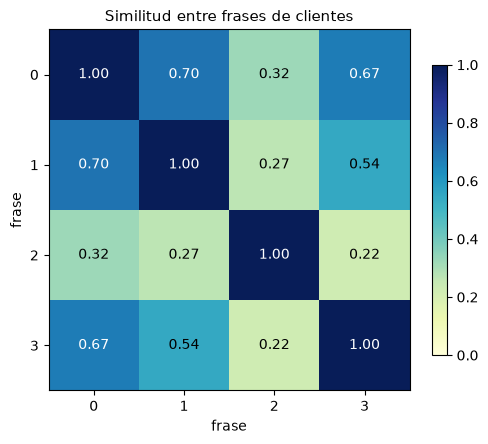

In [7]:
import matplotlib.pyplot as plt

# La misma matriz de arriba, pero en colores. Es más fácil ver un patrón en una
# imagen que en una lista de números.
fig, ax = plt.subplots(figsize=(5.2, 4.4))
mapa = ax.imshow(similitud, cmap="YlGnBu", vmin=0, vmax=1)

ax.set_xticks(range(len(FRASES)))
ax.set_yticks(range(len(FRASES)))
ax.set_xlabel("frase")
ax.set_ylabel("frase")
ax.set_title("Similitud entre frases de clientes", fontsize=11)

for i in range(len(FRASES)):
    for j in range(len(FRASES)):
        color = "white" if similitud[i][j] > 0.6 else "black"
        ax.text(j, i, f"{similitud[i][j]:.2f}", ha="center", va="center", color=color)

fig.colorbar(mapa, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 7. Un experimento con las dimensiones

Algo que sorprende. Si el significado está repartido en las cientos de dimensiones del vector,
¿qué pasa si nos quedamos solo con un pedazo al azar y tiramos el resto?

Debería romperse todo. Veamos.

In [8]:
import random

random.seed(7)   # para que el resultado sea reproducible en clase

# .shape[1] es cuántos números tiene cada vector. Vamos a quedarnos solo con una
# parte de ellos, para ver cuánta información se pierde al recortarlos.
total = normalizados.shape[1]
inicio = random.randint(0, total // 2)
fin = inicio + total // 4

recorte = normalizados[:, inicio:fin]
recorte = recorte / np.linalg.norm(recorte, axis=1, keepdims=True)
similitud_recorte = recorte @ recorte.T

print(f"Usando solo las dimensiones {inicio} a {fin} de {total} "
      f"({100 * (fin - inicio) / total:.0f}% del vector)\n")
print("      " + "".join(f"{i:>8}" for i in range(len(FRASES))))
for i, fila in enumerate(similitud_recorte):
    print(f"  [{i}] " + "".join(f"{v:>8.2f}" for v in fila))

Usando solo las dimensiones 165 a 357 de 768 (25% del vector)

             0       1       2       3
  [0]     1.00    0.70    0.34    0.71
  [1]     0.70    1.00    0.28    0.55
  [2]     0.34    0.28    1.00    0.21
  [3]     0.71    0.55    0.21    1.00


Los números cambian, pero el patrón se conserva: las frases que estaban cerca siguen cerca, y
las que estaban lejos siguen lejos. Con una cuarta parte del vector, elegida al azar, el
ordenamiento se mantiene.

Eso dice algo sobre cómo son estos modelos: el significado no está guardado en unas pocas
dimensiones críticas, está distribuido con mucha redundancia por todo el vector.

Y tiene una consecuencia práctica que ya se usa en producción. Algunos modelos están entrenados
para que puedas recortar el vector a la mitad o a un cuarto y quedarte con casi toda la
capacidad de distinguir, lo que reduce el tamaño del índice y acelera las búsquedas. No es un
truco casero: es una técnica deliberada de entrenamiento.

## 8. Elegir el modelo de embeddings, midiendo

Llegamos a la decisión que más pesa en la calidad de un sistema RAG, y la que más veces se toma
copiando lo que decía un tutorial.

El curso usa `embeddinggemma:300m`, y toca comprobar si esa elección se sostiene o si es una
costumbre disfrazada de criterio. Tenemos tres modelos disponibles y un documento en español.
Preparé seis preguntas de cliente cuya respuesta sé exactamente en qué fragmento está. Vamos a
medir cuántas veces cada modelo trae el fragmento correcto.

Esto es lo que se llama un conjunto de referencia, y es la única forma seria de comparar. Ojo
con lo que mide: no si la respuesta suena bien, sino si el fragmento que la contiene llegó al
modelo. Si no llegó, no hay modelo de lenguaje que arregle eso.

In [9]:
import re

from langchain_community.vectorstores import LanceDB

PREGUNTAS = [
    ("¿Cuánto cuesta el envío a Lima?", "lima metropolitana"),
    ("¿En cuántos días llega un pedido a la selva?", "selva"),
    ("¿Cuántos días tengo para devolver algo?", "treinta dias"),
    ("¿Quién paga el envío de una devolución?", "gastos de envio de la devolucion"),
    ("¿Cómo inicio una devolución?", "mis pedidos"),
    ("¿Cuándo me devuelven el dinero?", "cinco dias habiles"),
]

# Los tres modelos de embeddings que vamos a comparar. Ninguno es el mejor en
# abstracto: el bueno es el que recupera mejor con TUS documentos y TUS preguntas.
CANDIDATOS = ["nomic-embed-text", "embeddinggemma:300m", "mxbai-embed-large"]


def normalizar(texto):
    return re.sub(r"[^a-záéíóúñ ]", "", re.sub(r"\s+", " ", texto.lower()))


# Para cada modelo: construye el índice, hace las seis preguntas y cuenta en
# cuántas apareció la palabra clave dentro de los fragmentos recuperados.
# k=3 significa que la búsqueda devuelve los tres fragmentos más parecidos.
def evaluar_recuperacion(modelo, k=3):
    emb = OllamaEmbeddings(model=modelo)
    almacen = LanceDB.from_documents(fragmentos, emb, uri="lancedb_comparacion",
                                     table_name="comparacion", mode="overwrite")
    buscador = almacen.as_retriever(search_kwargs={"k": k})

    # Un acierto es que el fragmento correcto haya llegado al contexto. Aquí todavía
    # no medimos la respuesta del modelo, solo la búsqueda.
    aciertos, detalle = 0, []
    for pregunta, clave in PREGUNTAS:
        contexto = " ".join(d.page_content for d in buscador.invoke(pregunta))
        acierto = normalizar(clave) in normalizar(contexto)
        aciertos += acierto
        detalle.append("si" if acierto else "no")
    return aciertos, detalle


print(f"{'modelo':<22} {'aciertos':>9}   detalle por pregunta")
print("-" * 66)
for modelo in CANDIDATOS:
    try:
        aciertos, detalle = evaluar_recuperacion(modelo)
        print(f"{modelo:<22} {aciertos}/{len(PREGUNTAS):<7}   {' '.join(detalle)}")
    except Exception as e:
        print(f"{modelo:<22} no disponible ({type(e).__name__}). "
              f"Descárgalo con: ollama pull {modelo}")

modelo                  aciertos   detalle por pregunta
------------------------------------------------------------------


nomic-embed-text       5/6         si si si no si si


embeddinggemma:300m    6/6         si si si si si si


mxbai-embed-large      6/6         si si si si si si


Con este documento y estas preguntas, `nomic-embed-text`, el que aparece en la mayoría de los
tutoriales, queda último. Y aquí viene lo interesante: el que gana esta prueba **no** es el que
usa el curso. `mxbai-embed-large` suele salir arriba con documentos en español.

Entonces, ¿por qué el curso usa `embeddinggemma:300m`? Porque esta prueba mide un solo escenario,
el más fácil: documento en español, pregunta en español. Vamos a ver qué pasa cuando el corpus
mezcla idiomas, que es lo normal en cuanto sumas artículos, manuales de proveedores o
documentación técnica.

Armemos un índice con dos documentos a la vez: la política en español y un libro en inglés. Y
preguntemos en las cuatro combinaciones posibles, incluidas las cruzadas: preguntar en español
algo que solo está en el documento en inglés, y al revés.

In [10]:
# Ahora la prueba difícil: preguntar en un idioma cuando la respuesta está escrita
# en otro. Es el caso real de una empresa con manuales en inglés y clientes que
# escriben en español.
CRUZADAS = [
    ("es->es", "¿Cuánto cuesta el envío a Lima?", "lima metropolitana"),
    ("en->es", "How much does shipping to Lima cost?", "lima metropolitana"),
]

# Un documento en inglés para mezclar. Si no lo tienes, la celda lo salta.
OTRO = Path("documentos/Alice_in_Wonderland.pdf")

if OTRO.exists():
    doc_en = pymupdf.open(OTRO)
    texto_en = "\n".join(p.get_text() for p in doc_en)
    mixto = list(fragmentos) + [
        Document(page_content=t, metadata={"idioma": "en"})
        for t in RecursiveCharacterTextSplitter(
            chunk_size=1000, chunk_overlap=200).split_text(texto_en)]

    for f in fragmentos:
        f.metadata["idioma"] = "es"

    print(f"Corpus mixto: {len(fragmentos)} fragmentos en español "
          f"+ {len(mixto) - len(fragmentos)} en inglés\n")

    PRUEBAS = [
        ("pregunta en español, respuesta en el documento inglés",
         "¿Qué le dice el Gato de Cheshire sobre estar loco?", "en"),
        ("pregunta en inglés, respuesta en el documento español",
         "How much does shipping to Lima cost?", "es"),
    ]

    print(f"{'modelo':<22} {'caso 1':>9} {'caso 2':>9}")
    print("-" * 44)
    for candidato in CANDIDATOS:
        emb = OllamaEmbeddings(model=candidato)
        indice = LanceDB.from_documents(mixto, emb, uri="lancedb_mixto",
                                        table_name="mixto", mode="overwrite")
        buscador = indice.as_retriever(search_kwargs={"k": 5})
        resultados = []
        for _, pregunta, idioma_esperado in PRUEBAS:
            docs = buscador.invoke(pregunta)
            correctos = sum(1 for d in docs if d.metadata.get("idioma") == idioma_esperado)
            resultados.append(f"{correctos}/5")
        print(f"{candidato:<22} {resultados[0]:>9} {resultados[1]:>9}")

    print("\nLos números son cuántos de los 5 fragmentos recuperados están")
    print("en el idioma donde de verdad está la respuesta.")
else:
    print(f"No encontré {OTRO}, saltamos esta comparación.")

Corpus mixto: 10 fragmentos en español + 242 en inglés



modelo                    caso 1    caso 2
--------------------------------------------


nomic-embed-text             1/5       4/5


embeddinggemma:300m          5/5       5/5


mxbai-embed-large            0/5       5/5

Los números son cuántos de los 5 fragmentos recuperados están
en el idioma donde de verdad está la respuesta.


Ahí está la razón, y es más contundente de lo que uno esperaría.

Cuando la pregunta va en español y la respuesta está en el documento en inglés,
`mxbai-embed-large` y `nomic-embed-text` recuperan **cero** fragmentos en inglés. No es que
acierten menos: no cruzan la frontera del idioma en absoluto. Traen los cinco fragmentos en
español, aunque ninguno tenga la respuesta.

Lo que ocurre es que en el espacio vectorial de esos modelos el idioma pesa más que el tema. Dos
textos en español, hablando de cosas distintas, quedan más cerca entre sí que un texto en español
y su traducción al inglés. `embeddinggemma` está entrenado para que eso no pase, y por eso
recupera los cinco correctos.

Curiosamente el efecto es asimétrico: preguntando en inglés sobre el documento en español, esos
dos modelos sí cruzan bastante. Falla más en una dirección que en la otra.

De ahí la decisión del curso. `embeddinggemma` pierde por poco en español puro y gana por mucho
en cuanto hay mezcla. Como en el trabajo real los documentos vienen en los idiomas en que
vinieron, preferimos el que no se rompe.

Tres advertencias sobre estas mediciones, porque son parte de lo que hay que aprender.

Seis y diez preguntas son muy pocas. Un conjunto de referencia serio tiene decenas o cientos, y
aquí una sola pregunta mueve el resultado más de diez puntos. Sirven para ilustrar el método, no
para zanjar la discusión. El estándar de la industria para comparar recuperadores se llama BEIR y
reúne más de diecisiete conjuntos de datos con métricas como NDCG y MRR.

El resultado depende del escenario, como acabas de ver: el ganador cambió al cambiar la prueba.
Cuando alguien te presente un modelo como el mejor, la pregunta correcta es en qué condiciones lo
midió.

Y hay un detalle que penaliza a `nomic-embed-text`: ese modelo está entrenado para recibir un
prefijo que le diga si el texto es un documento o una consulta, y la librería que usamos no lo
agrega. Con los prefijos puestos mejora. Lo apunto porque es el tipo de asimetría que invalida una
comparación sin que uno se dé cuenta: no siempre estás midiendo el modelo, a veces estás midiendo
cómo lo llamas.

In [11]:
# Construimos el índice con el modelo del curso. Si en tu medición ganó otro,
# cambia MODELO_EMBEDDINGS en la sección 3 y vuelve a ejecutar desde aquí.
embeddings = OllamaEmbeddings(model=MODELO_EMBEDDINGS)
almacen = LanceDB.from_documents(fragmentos, embeddings, uri="lancedb",
                                 table_name="tiendasol", mode="overwrite")

print(f"Índice construido con {MODELO_EMBEDDINGS}")

Índice construido con embeddinggemma:300m


## 9. De la similitud a la búsqueda

Ya sabes medir el parecido entre dos textos. Buscar es hacer eso mismo contra todo el índice y
quedarse con los más cercanos.

Vale la pena hacerlo a mano una vez, sin la ayuda de la base de datos, para ver que no hay
magia: es una multiplicación y un ordenamiento.

In [12]:
pregunta = "¿Cuánto tarda en llegar un pedido a la selva?"

# Este bloque hace a mano lo que la base de datos hace por dentro, para que se vea
# que no hay magia: convertir la pregunta en vector, convertir todos los fragmentos
# en vectores, y ordenar por cercanía.
v_pregunta = np.array(embeddings.embed_query(pregunta))
v_pregunta = v_pregunta / np.linalg.norm(v_pregunta)

v_fragmentos = np.array(embeddings.embed_documents([f.page_content for f in fragmentos]))
v_fragmentos = v_fragmentos / np.linalg.norm(v_fragmentos, axis=1, keepdims=True)

# Un número por fragmento: qué tan cerca está de la pregunta.
puntajes = v_fragmentos @ v_pregunta
# argsort devuelve las posiciones ordenadas de menor a mayor; [::-1] le da la vuelta
# a la lista para que el primero sea el más parecido.
orden = np.argsort(puntajes)[::-1]

print(f"Pregunta: {pregunta}\n")
print("Los cinco fragmentos más cercanos:\n")
for posicion, indice in enumerate(orden[:5], 1):
    texto = " ".join(fragmentos[indice].page_content.split())
    print(f"  {posicion}. similitud {puntajes[indice]:.3f}  [{fragmentos[indice].metadata['tipo']}]")
    print(f"     {texto[:95]}")

Pregunta: ¿Cuánto tarda en llegar un pedido a la selva?

Los cinco fragmentos más cercanos:

  1. similitud 0.563  [tabla]
     Zona: Zona de selva; Plazo habil: 8 a 12 dias; Costo: S/ 29.90; Envio gratis desde: S/ 249
  2. similitud 0.518  [texto]
     de entrega se cuentan en dias habiles a partir de la confirmacion del pago, no de la fecha en q
  3. similitud 0.411  [tabla]
     Zona: Provincias, capital; Plazo habil: 3 a 5 dias; Costo: S/ 15.90; Envio gratis desde: S/ 149
  4. similitud 0.406  [tabla]
     Zona: Provincias, interior; Plazo habil: 5 a 8 dias; Costo: S/ 22.90; Envio gratis desde: S/ 19
  5. similitud 0.394  [tabla]
     Zona: Lima metropolitana; Plazo habil: 1 a 2 dias; Costo: S/ 9.90; Envio gratis desde: S/ 99


Eso es una búsqueda vectorial completa: comparar la pregunta contra todos los fragmentos y
ordenar por cercanía. Con diez fragmentos es instantáneo.

Con diez millones sería otra historia, porque el trabajo crece en proporción directa al tamaño
del índice. Por eso las bases de datos vectoriales no comparan contra todo: organizan los
vectores en capas, de lo general a lo particular, y bajan por ese árbol descartando regiones
enteras. Es como buscar una ciudad mirando primero el país, luego el estado, luego la comarca.

El nombre técnico es búsqueda aproximada, y la palabra aproximada es literal: puede devolver el
segundo más cercano en lugar del primero. A cambio, es órdenes de magnitud más rápida. En un
índice grande, ese cambio es lo que hace la diferencia entre un servicio usable y uno inviable.

## 10. Dónde guardar los vectores

Hemos usado LanceDB desde la primera práctica sin discutirlo. Vale la pena saber qué otras
opciones hay, porque es una decisión que se toma al principio de un proyecto y luego cuesta
cambiar.

Todas hacen lo mismo que acabas de programar a mano: guardar vectores y encontrar los más
cercanos. La diferencia está en dónde viven y qué exigen a cambio.

| Opción | Dónde vive | Qué necesitas | Cuándo conviene |
|---|---|---|---|
| LanceDB | una carpeta junto a tu código | nada más | prototipos, cursos, aplicaciones de un solo equipo |
| sqlite-vec | un archivo `.db` de SQLite | una extensión de SQLite | lo mismo, y si ya usas SQLite en el proyecto |
| pgvector | dentro de PostgreSQL | un servidor de base de datos | si la empresa ya tiene PostgreSQL y quiere todo en un lugar |
| Pinecone, Weaviate, Qdrant | un servicio en la nube o un servidor propio | cuenta, red, presupuesto | millones de fragmentos, varios equipos consultando |

Las dos primeras se llaman embebidas: no hay servidor que instalar ni encender, la base es un
archivo en tu disco. Por eso son las que se usan para aprender y para prototipos, y por eso
elegimos LanceDB para el curso.

pgvector no es una base distinta, es una extensión que le añade búsqueda vectorial a PostgreSQL.
Su ventaja no es técnica sino organizativa: si los datos de la empresa ya están en PostgreSQL,
poder buscar por significado ahí mismo evita mantener un sistema aparte y sincronizarlo.

Y algo que conviene tener claro antes de que alguien te venda un servicio: para el tamaño de
corpus con el que trabaja la mayoría de las empresas medianas, unas decenas de miles de
fragmentos, cualquiera de las embebidas alcanza de sobra. La complejidad de un servicio en la
nube se justifica por escala y por número de equipos que consultan, no por hacer RAG.

## 11. El parámetro k

`k` es cuántos fragmentos le pasamos al modelo. Es el parámetro que más se toca y el que más se
elige a ciegas.

Con k muy chico corres el riesgo de dejar fuera el fragmento que tenía la respuesta. Con k muy
grande metes ruido, gastas tiempo y le das al modelo más oportunidades de distraerse. Vamos a
verlo con números.

In [13]:
print(f"{'k':>3}  {'aciertos':>9}  {'caracteres de contexto':>23}")
print("-" * 40)

# k es cuántos fragmentos se le entregan al modelo. Subirlo mejora la probabilidad
# de incluir la respuesta, pero también mete ruido y hace la consulta más lenta y
# más cara. Esta celda busca el punto donde deja de valer la pena.
for k in (1, 2, 3, 5, 8):
    buscador = almacen.as_retriever(search_kwargs={"k": k})
    aciertos, tamano = 0, 0
    for pregunta, clave in PREGUNTAS:
        docs = buscador.invoke(pregunta)
        contexto = " ".join(d.page_content for d in docs)
        aciertos += normalizar(clave) in normalizar(contexto)
        tamano += len(contexto)
    print(f"{k:>3}  {aciertos:>4}/{len(PREGUNTAS):<4}  {tamano // len(PREGUNTAS):>23}")

  k   aciertos   caracteres de contexto
----------------------------------------


  1     5/6                         299


  2     5/6                         668


  3     6/6                         908


  5     6/6                        1702


  8     6/6                        2537


Ahí está el intercambio, y en tu propia medición. Al subir k aumentan los aciertos, porque es
más difícil que el fragmento correcto se quede fuera, pero el contexto crece y con él el tiempo
de respuesta y el ruido.

Fíjate en dónde deja de mejorar. A partir de cierto punto, subir k ya no gana aciertos y solo
suma caracteres. Ese punto es distinto para cada conjunto de documentos, y encontrarlo con una
medición como esta cuesta un minuto.

## 12. La instrucción que recibe el modelo

Ya tenemos los fragmentos correctos. Falta pedirle bien las cosas al modelo.

En la práctica 1 usamos una instrucción mínima. Vamos a mejorarla, y a ver que cada cambio
responde a un problema concreto.

In [14]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

# El modelo que redacta la respuesta. temperature=0 hace que, ante la misma
# pregunta, conteste siempre lo mismo: justo lo que se quiere en atención al cliente.
#
# Aquí es donde una organización pondría la llamada a un servicio comercial si
# decidiera no usar un modelo local. Este curso corre en local a propósito.
llm = ChatOllama(model=MODELO_LLM, temperature=0)
buscador = almacen.as_retriever(search_kwargs={"k": 3})


# Los fragmentos recuperados llegan como objetos. El modelo necesita texto plano,
# así que los pegamos uno tras otro marcando de qué tipo es cada uno.
def formatear(docs):
    return "\n\n".join(
        f"[{d.metadata['tipo']}] {d.page_content}" for d in docs)


# Una plantilla es el texto que se le manda al modelo, con dos huecos: {context} se
# llena con los fragmentos recuperados y {question} con la pregunta del cliente.
# Esta primera versión es la mínima posible, a propósito.
PLANTILLA_BASICA = ChatPromptTemplate.from_template(
    """Responde la pregunta usando únicamente el contexto siguiente.

Contexto:
{context}

Pregunta: {question}"""
)

# La misma tarea, pero diciéndole quién es, en qué idioma responder, de qué largo
# y, lo más importante, que tiene permiso de decir que no sabe.
PLANTILLA_CUIDADA = ChatPromptTemplate.from_template(
    """Eres un asistente del centro de ayuda de una tienda en línea.

Responde la pregunta del cliente usando únicamente la información del contexto.
Si el contexto no contiene la respuesta, dilo con claridad y no ofrezcas suposiciones.
Responde en español, en dos o tres oraciones, con los datos concretos que pida.

Pregunta del cliente: {question}

Contexto:
{context}"""
)


# El flujo completo en tres pasos: buscar, armar el texto, pedir la respuesta.
# El símbolo | encadena las piezas: la plantilla alimenta al modelo y lo que sale
# pasa por StrOutputParser, que se queda solo con el texto de la respuesta.
def responder(plantilla, pregunta):
    docs = buscador.invoke(pregunta)
    cadena = plantilla | llm | StrOutputParser()
    return cadena.invoke({"context": formatear(docs), "question": pregunta}).strip()


pregunta = "¿Cuánto cuesta enviar a la selva y en cuántos días llega?"
print("CON LA PLANTILLA MÍNIMA:\n")
print(responder(PLANTILLA_BASICA, pregunta))
print("\n" + "-" * 78)
print("\nCON LA PLANTILLA CUIDADA:\n")
print(responder(PLANTILLA_CUIDADA, pregunta))

CON LA PLANTILLA MÍNIMA:



Según el contexto, enviar a la zona de selva cuesta S/ 29.90 y tarda entre 8 y 12 días hábiles.

------------------------------------------------------------------------------

CON LA PLANTILLA CUIDADA:



El envío a la selva tiene un costo de S/ 29.90 y tarda entre 8 y 12 días hábiles. Para que el envío a la zona de selva sea gratuito, tu pedido debe tener un valor de al menos S/ 249.


Tres decisiones dentro de esa segunda plantilla, y ninguna es decorativa.

La pregunta va antes del contexto. Los modelos atienden mejor al principio y al final de lo que
reciben, y si el contexto es largo, una pregunta enterrada al final se diluye.

Se le dice qué es y a quién atiende. Eso ajusta el tono y el nivel de detalle sin tener que
pedirlo cada vez.

Y se le da permiso explícito de no saber. Sin esa línea, un modelo tiende a completar el hueco
con algo que suene razonable, porque es lo que aprendió a hacer.

## 13. Cuando la respuesta no está

Esa última línea es la que conviene probar en serio. Preguntemos algo que el documento no
responde.

In [15]:
fuera_de_alcance = "¿Puedo pagar mi pedido en criptomonedas?"

print("SIN el permiso de no saber:\n")
print(responder(PLANTILLA_BASICA, fuera_de_alcance))
print("\n" + "-" * 78)
print("\nCON el permiso de no saber:\n")
print(responder(PLANTILLA_CUIDADA, fuera_de_alcance))

SIN el permiso de no saber:



El texto no proporciona información sobre si se pueden pagar los pedidos con criptomonedas.

------------------------------------------------------------------------------

CON el permiso de no saber:



Lo siento, no tengo información sobre si puedes pagar tu pedido en criptomonedas. La información proporcionada se refiere a zonas de envío y sus costos asociados.


El documento de TiendaSol no dice nada sobre criptomonedas. La respuesta correcta es admitirlo.

En un sistema de atención a clientes esto no es un detalle de estilo. Una respuesta inventada
sobre métodos de pago genera un reclamo, y quizá una obligación que la empresa no ofrece. Un
"no tengo esa información, te comunico con un asesor" no genera nada de eso.

Vale la pena que pruebes varias preguntas fuera de alcance y veas cuántas veces cada plantilla
resiste. No siempre resiste: la instrucción reduce las invenciones, no las elimina.

## 14. Evaluar las respuestas

Última pieza, y la que separa un prototipo de algo que puedes defender ante alguien.

Hasta ahora hemos juzgado las respuestas leyéndolas. Eso no escala: con veinte preguntas y tres
configuraciones son sesenta lecturas, y el criterio cambia según el ánimo.

La alternativa es usar un modelo como evaluador. Se le da la pregunta, el contexto y la
respuesta, y se le pide calificar dos cosas distintas:

La pertinencia, que es si la respuesta contesta lo que se preguntó. Y la fidelidad, que es si
todo lo que afirma está respaldado por el contexto. Son independientes: una respuesta puede ser
muy pertinente y estar inventada, o ser fiel al documento y no venir al caso.

In [16]:
import json

# Un segundo modelo que lee la pregunta, el contexto y la respuesta, y pone nota.
# Le pedimos JSON porque es un formato que el programa puede leer sin adivinar.
# Las llaves dobles {{ }} son para que la plantilla no confunda ese JSON con un hueco.
JUEZ = ChatPromptTemplate.from_template(
    """Evalúa una respuesta de un asistente de atención a clientes.

Califica dos aspectos, cada uno del 1 al 5:
- pertinencia: ¿la respuesta contesta la pregunta?
- fidelidad: ¿todo lo que afirma está respaldado por el contexto?

Responde únicamente con un objeto JSON, sin texto adicional, con esta forma exacta:
{{"pertinencia": <1-5>, "fidelidad": <1-5>, "motivo": "<una oración>"}}

Pregunta: {question}

Contexto entregado:
{context}

Respuesta a evaluar:
{answer}"""
)


def calificar(pregunta, respuesta):
    """Pide una calificación al modelo y la interpreta sin confiar en el formato."""
    docs = buscador.invoke(pregunta)
    cadena = JUEZ | llm | StrOutputParser()
    crudo = cadena.invoke({"question": pregunta, "context": formatear(docs),
                           "answer": respuesta})

    nota = {"pertinencia": None, "fidelidad": None, "motivo": ""}
    try:
        # Muchos modelos envuelven el JSON en un bloque de markdown, así que
        # nos quedamos con lo que hay entre la primera llave y la última.
        recorte = crudo[crudo.index("{"):crudo.rindex("}") + 1]
        crudo_json = json.loads(recorte)

        # Y algunos devuelven las claves con espacios de sobra, por ejemplo
        # " pertinencia" en lugar de "pertinencia". Las normalizamos.
        datos = {str(k).strip().lower(): v for k, v in crudo_json.items()}

        for clave in ("pertinencia", "fidelidad"):
            valor = datos.get(clave)
            nota[clave] = valor if isinstance(valor, (int, float)) else None
        nota["motivo"] = str(datos.get("motivo", "")).strip()
    except (ValueError, AttributeError, json.JSONDecodeError):
        nota["motivo"] = f"no se pudo interpretar la calificación: {crudo[:70]}"

    return nota


# Tres preguntas a propósito distintas: una fácil, una de plazo, y una cuya
# respuesta no está en los documentos. La tercera es la que separa un sistema
# honesto de uno que inventa.
A_EVALUAR = [
    "¿Cuánto cuesta el envío a Lima?",
    "¿Cuántos días tengo para devolver un producto?",
    "¿Puedo pagar en criptomonedas?",
]

print(f"{'pregunta':<46} {'pert.':>6} {'fidel.':>7}")
print("-" * 62)
for pregunta in A_EVALUAR:
    respuesta = responder(PLANTILLA_CUIDADA, pregunta)
    nota = calificar(pregunta, respuesta)
    pert = nota["pertinencia"] if nota["pertinencia"] is not None else "-"
    fidel = nota["fidelidad"] if nota["fidelidad"] is not None else "-"
    print(f"{pregunta[:44]:<46} {str(pert):>6} {str(fidel):>7}")
    print(f"   respuesta: {respuesta[:100]}")
    print(f"   motivo:    {nota['motivo'][:100]}\n")

pregunta                                        pert.  fidel.
--------------------------------------------------------------


¿Cuánto cuesta el envío a Lima?                     5       5
   respuesta: El costo del envío a Lima Metropolitana es de S/ 9.90.  También, el envío es gratuito si tu compra s
   motivo:    La respuesta proporciona la información solicitada sobre el costo del envío a Lima Metropolitana y l



¿Cuántos días tengo para devolver un product        5       5
   respuesta: Tienes treinta días calendario a partir de la entrega para devolver el producto, siempre que conserv
   motivo:    La respuesta proporciona la información clave sobre el plazo de devolución (30 días) y el tiempo adi



¿Puedo pagar en criptomonedas?                      1       5
   respuesta: No puedo responder a tu pregunta sobre el pago con criptomonedas. La información proporcionada solo 
   motivo:    La respuesta es pertinente porque reconoce que no puede responder a la pregunta, pero la fidelidad e



Con esto ya puedes comparar configuraciones sin leerlas todas: cambia el modelo, o k, o la
plantilla, y mira si los promedios suben.

Ahora las limitaciones, que son importantes y conviene decirlas antes de que alguien te las
señale.

El evaluador es el mismo tipo de modelo que está evaluando, y puede equivocarse igual.

Y no respeta el formato que le pides, por más claro que se lo pongas. Esto no es una suposición:
al probar esta misma celda con dos modelos distintos, uno devolvió el JSON envuelto en un bloque
de markdown, y el otro lo devolvió limpio pero escribiendo la clave como `" pertinencia"`, con un
espacio adelante. Las dos respuestas son JSON válido y las dos rompen un programa que confíe en
recibir exactamente lo que pidió.

Por eso la función de arriba hace tres cosas antes de creerle al modelo: recorta lo que haya
entre la primera llave y la última, quita los espacios sobrantes de los nombres de las claves, y
comprueba que las calificaciones sean números antes de usarlas. Si algo falla, devuelve un guión
en lugar de tumbar el cuaderno.

Llévate ese hábito más que el código. En cuanto conectas la salida de un modelo con un programa
que sigue corriendo, tienes que tratarla como lo que es: texto de fuera, sobre el que no mandas.

Tampoco es consistente: la misma respuesta puede recibir notas distintas en dos corridas.

Y hay un riesgo de fondo: si el mismo modelo genera y califica, tiende a aprobarse a sí mismo.

Aun así es útil, porque no lo estamos usando para dar una nota absoluta, sino para comparar dos
configuraciones bajo el mismo criterio. Para eso, un evaluador imperfecto pero consistente en
su sesgo sirve. Lo que no puedes es presentar un promedio de estos como si fuera una medición
objetiva de calidad. Para una decisión importante, una muestra revisada por una persona sigue
siendo el patrón contra el que se comparan los demás métodos.

## 15. Lo que ya sabes hacer

Entre las tres prácticas construiste un sistema RAG completo y, más importante, aprendiste a
inspeccionarlo por dentro en cada etapa.

Puedes separar el contenido útil de un documento del que estorba. Puedes fragmentarlo con
criterio y saber qué cambia con cada estrategia. Sabes qué es un embedding y por qué la
elección del modelo pesa más que la del modelo que redacta. Sabes buscar y ajustar cuántos
fragmentos traer, midiendo en lugar de adivinando. Y sabes escribirle al modelo una instrucción
que lo mantenga pegado al documento, y comprobar si lo cumplió.

Lo que queda para adelante, y que ya viste marcado en las figuras:

La búsqueda por significado falla con nombres propios, códigos de producto y números exactos,
porque un vector no distingue bien entre dos referencias parecidas. La solución es combinarla
con búsqueda por palabras.

El orden en que llegan los fragmentos importa, y el buscador no siempre acierta al ordenarlos.
Un paso de reordenamiento posterior mejora bastante.

Los metadatos que guardaste todavía no se usan para filtrar antes de buscar.

Y sobre todo: un sistema en producción necesita saber cuándo callarse, medir su desempeño de
forma continua y dejar rastro de qué contestó y con qué fundamento.